In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import h5py, os, tqdm, glob, scipy
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

os.environ["JAX_PLATFORM_NAME"] = "cpu"
import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm import camels

print(jax.devices())
print(jax.default_backend())

[CpuDevice(id=0)]
cpu


In [40]:
def halo_profile_3d(particle_pos, halo_pos, particles_in_halo_pos, num_bins=32, mesh_per_dim=512, box_size=25.0):
    particle_pos = particle_pos * mesh_per_dim / box_size
    halo_pos = halo_pos * mesh_per_dim / box_size
    particles_in_halo_pos = particles_in_halo_pos * mesh_per_dim / box_size
    
    # rho_field = cic_paint(jnp.zeros([mesh_per_dim]*3), particle_pos)
    
    rho_field = cic_paint(jnp.zeros([mesh_per_dim]*3), particles_in_halo_pos)

    nx, ny, nz = rho_field.shape
    x = jnp.arange(nx) - halo_pos[0]
    y = jnp.arange(ny) - halo_pos[1]
    z = jnp.arange(nz) - halo_pos[2]
    xx, yy, zz = jnp.meshgrid(x, y, z, indexing="ij")
    # distance from halo center
    rr = jnp.sqrt(xx**2 + yy**2 + zz**2)

    # create bins up to the max distance
    r_min = rr.min()
    r_max = jnp.quantile(jnp.sqrt(jnp.sum((particles_in_halo_pos - halo_pos) ** 2, axis=-1)), 0.95)
    bins = jnp.linspace(r_min, r_max, num_bins + 1)
    indices = jnp.digitize(rr, bins) - 1

    # sum mass in each radial bin
    mass_in_bin = []
    for i in range(num_bins):
        mass_in_bin.append(jnp.sum(rho_field * (indices == i)))
    mass_in_bin = jnp.array(mass_in_bin)

    # radius for each bin (midpoint)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, mass_in_bin


# data

In [20]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0
rng = np.random.default_rng(125)

In [21]:
# mesh_per_dim = 256
# mesh_shape = [mesh_per_dim] * 3
# box_size = 25.0
# rng = np.random.default_rng(125)

In [22]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS"
CODE = "SIMBA"
# CODE = "Astrid"
SIMSET = "CV"
RUN = "CV_0"

# i_snapshots = list(range(33, 0, -8))
# # i_snapshots = list(range(45, 0, -8))
# i_snapshots.sort()
i_snapshots = [-1]

SNAPSHOT = os.path.join(CAMELS, "Sims", CODE + "_DM", SIMSET, RUN, "snapshot_090.hdf5")
CATALOG = os.path.join(CAMELS, "FOF_Subfind", CODE + "_DM", SIMSET, RUN, "groups_090.hdf5")

In [23]:
# nbody_dict = camels.load_CV_snapshots(
#     os.path.join(CAMELS, "Sims", CODE + "_DM", SIMSET, RUN),
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=False
# )

# cosmo = nbody_dict["cosmo"]
# scales = nbody_dict["scales"]

# dm_pos = nbody_dict["dm_poss"]
# dm_vel = nbody_dict["dm_vels"]
# rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

In [24]:
# with h5py.File(SNAPSHOT, "r") as f:
#     dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
#     dm_ids = f["PartType1/ParticleIDs"][:]
    
# # i_sub = rng.choice(dm_ids, parts_per_dim**3, replace=False)
# # dm_ids = dm_ids[i_sub]
# # dm_pos = dm_pos[dm_ids]

# # rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

In [25]:
# with h5py.File(CATALOG, "r") as f:
#     h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
#     h_mass = f['Group/GroupMass'][:] * 1e10
#     h_len = f['Group/GroupLen'][:]
#     h_ids = f['IDs']['ID'][:]

# plots

(378047, 3)


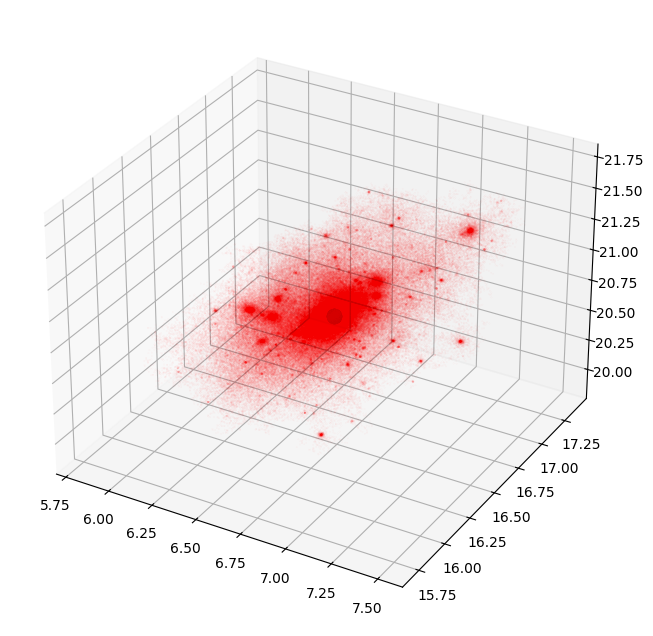

In [52]:
with h5py.File(SNAPSHOT, "r") as f:
    # dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_pos = f["PartType1/Coordinates"][:] / 1e3
    dm_ids = f["PartType1/ParticleIDs"][:]

with h5py.File(CATALOG, "r") as f:
    # h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_pos = f['Group/GroupPos'][:] / 1e3
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

# i_halo = np.argmax(h_mass)
i_halo = 2
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
halo_pos = h_pos[i_halo]

dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
print(dm_pos_halo.shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

(5783, 3)


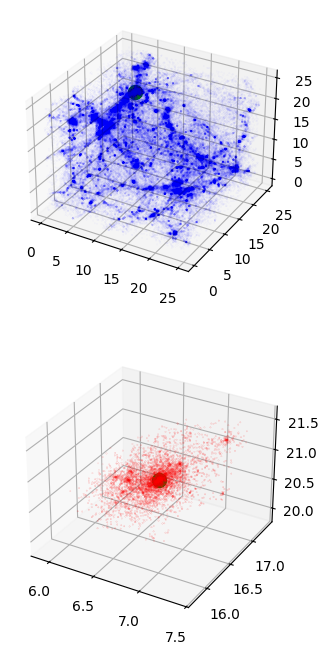

In [57]:
with h5py.File(SNAPSHOT, "r") as f:
    # dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_pos = f["PartType1/Coordinates"][:] / 1e3
    dm_ids = f["PartType1/ParticleIDs"][:]

with h5py.File(CATALOG, "r") as f:
    # h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_pos = f['Group/GroupPos'][:] / 1e3
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

# i_halo = np.argmax(h_mass)
i_halo = 2
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]

i_sub = rng.choice(dm_ids, parts_per_dim**3, replace=False)
dm_pos = dm_pos[np.isin(dm_ids, i_sub)]
dm_pos_halo = dm_pos_halo[np.isin(h_ids_halo, i_sub)]
print(dm_pos_halo.shape)

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(211, projection='3d')

ax.scatter(dm_pos[:, 0], dm_pos[:, 1], dm_pos[:, 2], c='b', marker='o', alpha=0.1, s=0.01)
ax.scatter(dm_pos_halo[:, 0], dm_pos_halo[:, 1], dm_pos_halo[:, 2], c='r', marker='o', s=0.01)
ax.scatter(h_pos[i_halo,0], h_pos[i_halo,1], h_pos[i_halo,2], c='g', marker='o', s=100)

ax = fig.add_subplot(212, projection='3d')
ax.scatter(dm_pos_halo[:, 0], dm_pos_halo[:, 1], dm_pos_halo[:, 2], c='r', marker='o', s=0.01)
ax.scatter(h_pos[i_halo,0], h_pos[i_halo,1], h_pos[i_halo,2], c='g', marker='o', s=100)

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass')]

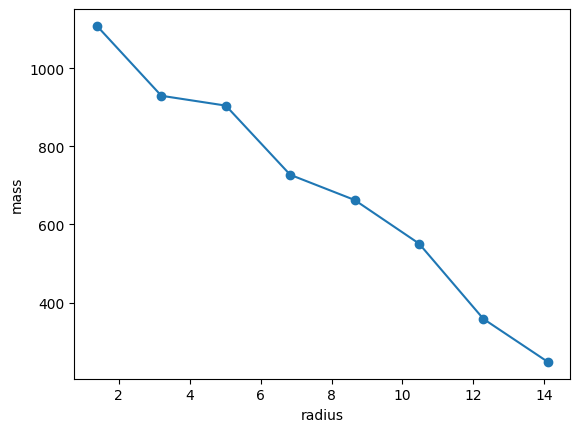

In [58]:
r, profile = halo_profile_3d(dm_pos, halo_pos, dm_pos_halo, num_bins=8)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
ax.set(xlabel="radius", ylabel="mass")
# ax.set(xlabel="radius", ylabel="mass", xscale="log", yscale="log")

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass')]

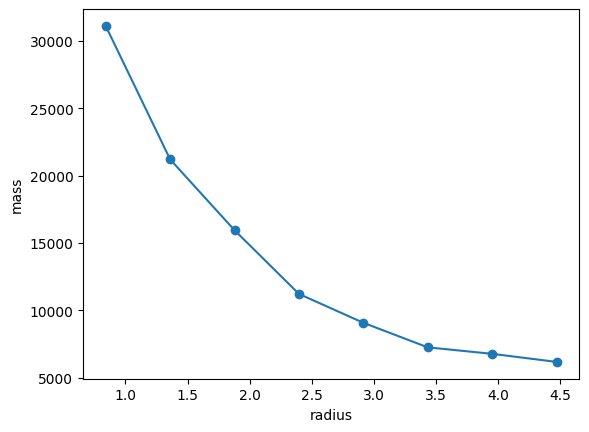

In [34]:
rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)
halo_pos = h_pos[i_halo]

r, profile = halo_profile_3d(rho_dm, halo_pos, dm_pos_halo, num_bins=8)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
ax.set(xlabel="radius", ylabel="mass")

(array([1.4510000e+03, 6.3080000e+03, 1.4859000e+04, 2.7110000e+04,
        4.2962000e+04, 8.5564000e+04, 8.4559000e+04, 1.0377700e+05,
        1.2495300e+05, 1.6285673e+07]),
 array([ 0. ,  3.2,  6.4,  9.6, 12.8, 16. , 19.2, 22.4, 25.6, 28.8, 32. ]),
 <BarContainer object of 10 artists>)

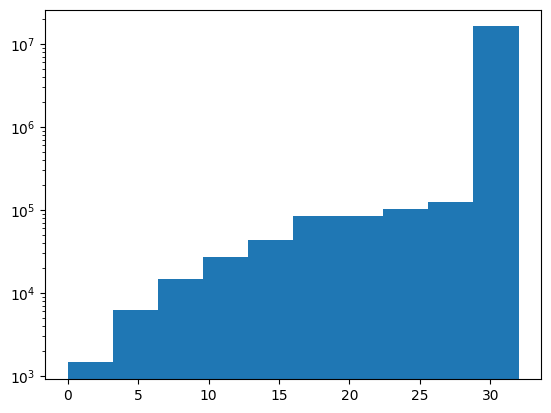

In [41]:
plt.hist(indices.ravel(), log=True)

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass')]

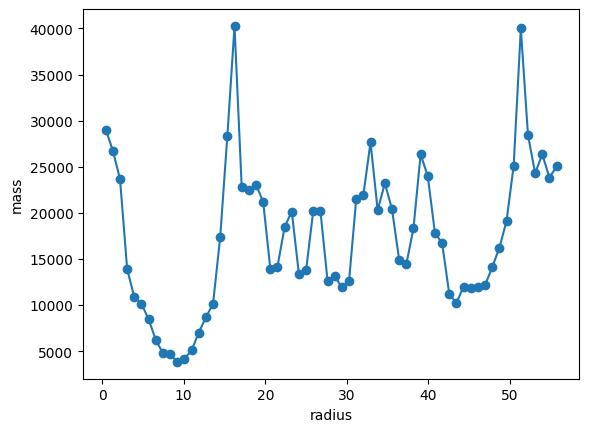

In [40]:
num_bins = 64
rho = cic_paint(jnp.zeros(mesh_shape), dm_pos)
halo_pos = h_pos[i_halo]

nx, ny, nz = rho.shape
x = jnp.arange(nx) - halo_pos[0]
y = jnp.arange(ny) - halo_pos[1]
z = jnp.arange(nz) - halo_pos[2]
xx, yy, zz = jnp.meshgrid(x, y, z, indexing='ij')
# distance from halo center
rr = jnp.sqrt(xx**2 + yy**2 + zz**2)  

# Create bins up to the max distance
r_max = jnp.sum((dm_pos_halo - halo_pos)**2, axis=-1).max()
# r_max = 10
# r_max = 2.5
bins = jnp.linspace(0, r_max, num_bins+1)
indices = jnp.digitize(rr, bins) - 1

# Sum mass in each radial bin
mass_in_bin = []
for i in range(num_bins):
    mass_in_bin.append(jnp.sum(rho * (indices == i)))
mass_in_bin = jnp.array(mass_in_bin)

# Radius for each bin (midpoint)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots()
ax.plot(bin_centers, mass_in_bin, marker='o')
# ax.set(xscale="log", yscale="log", xlabel="radius", ylabel="mass")
ax.set(xlabel="radius", ylabel="mass")

In [35]:
bins

Array([ 0.  ,  1.25,  2.5 ,  3.75,  5.  ,  6.25,  7.5 ,  8.75, 10.  ],      dtype=float32)

In [36]:
rr.min()

Array(0.582024, dtype=float32)

In [37]:
indices.min()

Array(1, dtype=int32)

In [211]:
dm_pos_halo.shape

(1758, 3)

In [212]:
halo_pos.shape

(3,)

In [215]:
jnp.sum((dm_pos_halo - halo_pos)**2, axis=-1).max()

Array(2.5048172, dtype=float32)

In [ ]:
def halo_profile_3d(rho, halo_pos, halo_dm_pos, num_bins=32):
    nx, ny, nz = rho.shape
    x = jnp.arange(nx) - h_pos[0]
    y = jnp.arange(ny) - h_pos[1]
    z = jnp.arange(nz) - h_pos[2]
    xx, yy, zz = jnp.meshgrid(x, y, z, indexing='ij')
    # distance from halo center
    rr = jnp.sqrt(xx**2 + yy**2 + zz**2)  

    # Create bins up to the max distance
    r_max = jnp.max(rr)
    bins = jnp.linspace(0, r_max, num_bins+1)
    indices = jnp.digitize(rr, bins) - 1

    # Sum mass in each radial bin
    mass_in_bin = []
    for i in range(num_bins):
        mass_in_bin.append(jnp.sum(grid * (indices == i)))
    mass_in_bin = jnp.array(mass_in_bin)

    # Radius for each bin (midpoint)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, mass_in_bin




In [10]:
def halo_profile_3d(grid, center, num_bins=32):
    # grid shape: (64,64,64), center: (cx, cy, cz)
    nx, ny, nz = grid.shape
    x = jnp.arange(nx) - center[0]
    y = jnp.arange(ny) - center[1]
    z = jnp.arange(nz) - center[2]
    xx, yy, zz = jnp.meshgrid(x, y, z, indexing='ij')
    rr = jnp.sqrt(xx**2 + yy**2 + zz**2)  # distance from center

    # Create bins up to the max distance
    r_max = jnp.max(rr)
    bins = jnp.linspace(0, r_max, num_bins+1)
    indices = jnp.digitize(rr, bins) - 1

    # Sum mass in each radial bin
    mass_in_bin = []
    for i in range(num_bins):
        mass_in_bin.append(jnp.sum(grid * (indices == i)))
    mass_in_bin = jnp.array(mass_in_bin)

    # Radius for each bin (midpoint)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, mass_in_bin




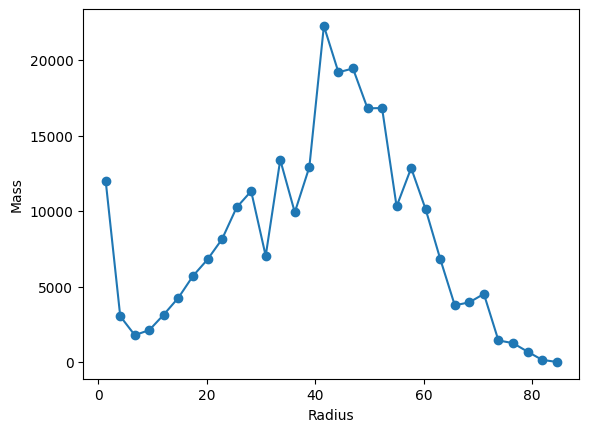

In [12]:
r, profile = halo_profile_3d(rho_dm, h_pos[0])

plt.plot(r, profile, marker='o')
plt.xlabel("Radius")
plt.ylabel("Mass")
plt.show()